# Import Library

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

###Loading the Dataset

In [ ]:
# Make sure the 'StutentsPerformance.csv' is uploaded to colab

df = pd.read_csv('StudentsPerformance.csv')

# Varify that the data is loaded by showing the first few rows
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


##Data Quality Check

In [ ]:
# Check for missing values and duplicates to ensure data quality

print("checking for missing values:")
print(df.isnull().sum())

print("\nChecking for duplicate rows:")
print(df.duplicated().sum())


#Get a summary of the dataset's stucture
df.info()

checking for missing values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Checking for duplicate rows:
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-n

##Visualizing Categorical Data (EDA)

/tmp/ipykernel_19994/3138559291.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='gender', palette='magma')


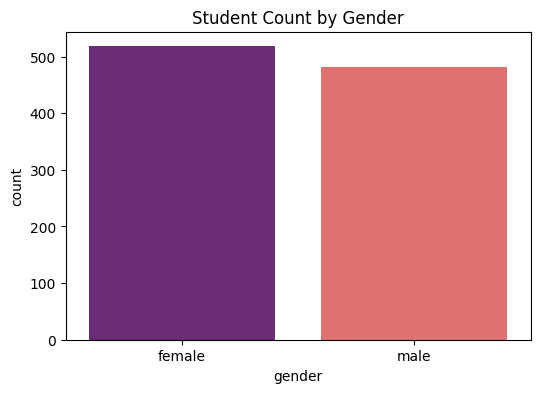

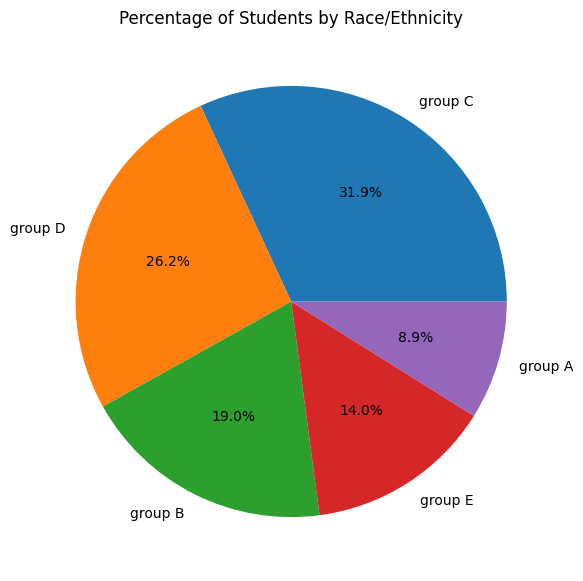

In [ ]:
# Visualing the distribution of gender
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='gender', palette='magma')
plt.title('Student Count by Gender')
plt.show()

# Visualize the race/ethnicity distribution
df['race/ethnicity'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(7,7))
plt.title('Percentage of Students by Race/Ethnicity')
plt.ylabel('')
plt.show()

## Deep aAnalysis of Scores

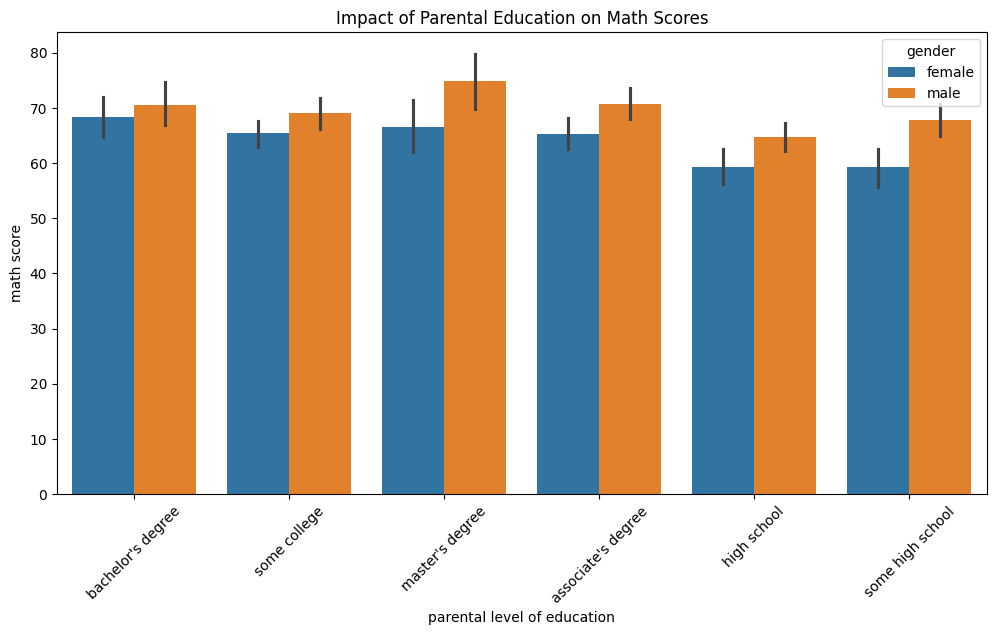

In [ ]:
# Analyze the relationship between Parental Education and Math Scores
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='parental level of education', y='math score', hue='gender')
plt.title('Impact of Parental Education on Math Scores')
plt.xticks(rotation=45) # Rotate labels for better readability
plt.show()

## Feature Engineering

In [ ]:
# Creating Total Score and Average Score featurs

# We sum the three subject score to get a comprehensive view parformance

df['total_score'] = df['math score'] + df['reading score'] + df['writing score']

df['average_score'] = df['total_score']/3

# Preview the updated dataset with new columns
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


## Categorical Data Encoding

In [ ]:
# Label Encoding categorical text data into numerical values

le = LabelEncoder()

# Fixed the spelling and case of column names
categorical_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Verify the transformation
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score
0,0,1,1,1,1,72,72,74,218,72.666667
1,0,2,4,1,0,69,90,88,247,82.333333
2,0,1,3,1,1,90,95,93,278,92.666667
3,1,0,0,0,1,47,57,44,148,49.333333
4,1,2,4,1,1,76,78,75,229,76.333333


## Train-Test Split

In [ ]:
# Define Feraures (X) by droping into Traing and Testing sets

X = df.drop(['math score', 'reading score', 'writing score', 'total_score', 'average_score'], axis=1)

# Define Target (y) predicting the student's average score
y = df['average_score']


# Split data: 80% for training and 20% for tersting
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.2, random_state=42)

#Output the size of the resulting sets
print("Training set features shape:", X_train.shape)
print("Testing set features shape:", X_test.shape)

Training set features shape: (800, 5)
Testing set features shape: (200, 5)


## Model Training

In [ ]:
# Training the Random Forest Regressor model

model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model with training data

model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

## Model Evaluation

In [ ]:
# Evaluating the Model performance

y_pred = model.predict(X_test)

# Calculate Accuracy Metrics

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared Score (Accuracy): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

R-squared Score (Accuracy): -0.0286
Mean Absolute Error (MAE): 11.5401


## Feature Importance

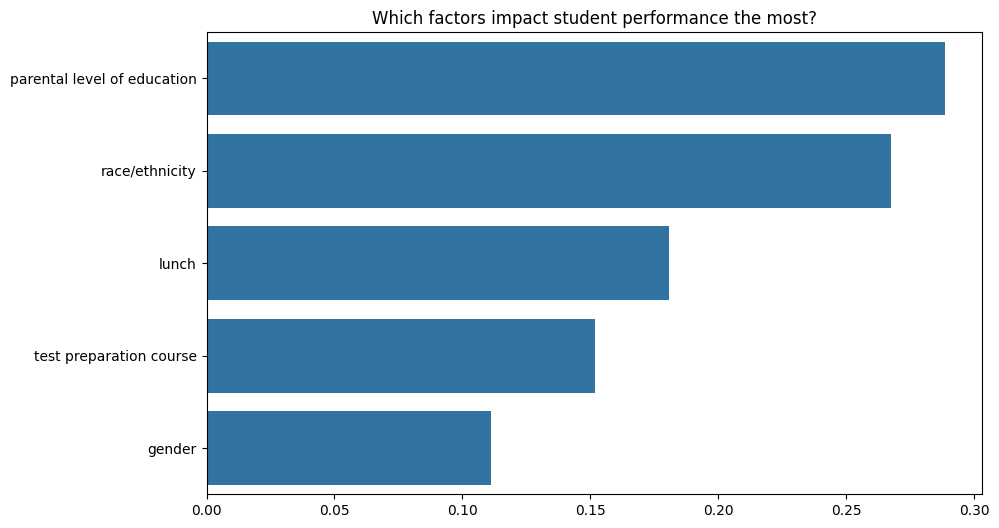

In [ ]:
# Identifiying the most important features

importances = model.feature_importances_
feature_names = X.columns

# Sort the feature importances in decending order
indices = np.argsort(importances)[::-1]
sorted_feature_names = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

# Ploting the features importance
plt.figure(figsize=(10,6))
sns.barplot(x=sorted_importances, y=sorted_feature_names)
plt.title('Which factors impact student performance the most?')
plt.show()

## Predict for a New Student

In [ ]:
 # Let's define a new student's profile based on our encoded values:
# gender: 0 (female), 1 (male)
# race/ethnicity: 0-4 (Group A to E)
# parental level of education: 0-5 (based on alphabetical order after encoding)
# lunch: 0 (free/reduced), 1 (standard)
# test preparation course: 0 (completed), 1 (none)

# Predict for a female student from group c, parents have a master's degree
new_student = np.array([[1, 2, 3, 1, 0]])

# Make the prediction
predicted_score = model.predict(new_student)

print(f"The predicted average score for this student is : {predicted_score[0]:.2f}")

The predicted average score for this student is : 81.91


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
